# Module 00 — The Perceptron

### *Can a machine learn a decision from examples?*

In 1943 McCulloch & Pitts modelled a neuron as a thresholded weighted sum. In 1957 Rosenblatt
turned that model into something that **learns**: the *perceptron*, with a rule for nudging the
weights whenever it gets an example wrong. It was the first machine that improved from data —
and the first to hit a wall (XOR) that took another 30 years to climb.

This notebook rebuilds the perceptron **from scratch, one cell at a time**, watches its decision
boundary rotate into place, runs it into the XOR wall, and finally **verifies** the inline code
agrees bit-for-bit with the canonical [`python/perceptron.py`](python/perceptron.py) (which in
turn matches the C in [`c/perceptron.c`](c/perceptron.c)).

> **How to run:** execute cells top-to-bottom (`Shift+Enter`). Needs only `numpy` + `matplotlib`;
> the interactive slider is optional (`ipywidgets`). See [`requirements.txt`](../../requirements.txt).

## 1. The intuition

A perceptron takes an input $\mathbf{x}$, forms a weighted sum plus a bias, and **fires**
(predicts class 1) when that sum crosses zero:

- weights $\mathbf{w}$ say *how much each input matters*,
- the bias $b$ shifts the threshold,
- the **step** at $0$ turns a continuous score into a yes/no decision.

Geometrically the boundary $\mathbf{w}\cdot\mathbf{x} + b = 0$ is a straight line; the perceptron
asks only *which side of the line* a point is on. Learning = rotating and shifting that line.

## 2. The math (all of it)

**Score / pre-activation**

$$ z = \mathbf{w}\cdot\mathbf{x} + b = w_0 x_0 + w_1 x_1 + b $$

**Prediction** (unit step)

$$ \hat{y} = \begin{cases} 1 & z \ge 0 \\ 0 & z < 0 \end{cases} $$

**Rosenblatt's learning rule** — on every example, move the weights toward the truth by the
error $(y - \hat{y}) \in \{-1, 0, +1\}$, scaled by a learning rate $\eta$:

$$ \mathbf{w} \leftarrow \mathbf{w} + \eta\,(y - \hat{y})\,\mathbf{x}, \qquad b \leftarrow b + \eta\,(y - \hat{y}) $$

When the prediction is right the error is $0$ and nothing changes. When it is wrong the line
rotates toward the misclassified point. On linearly-separable data this is *guaranteed* to
converge (Rosenblatt's perceptron convergence theorem).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.figsize"] = (6, 5)

## 3. A deterministic RNG (why bit-exactness matters)

The whole project's contract is that **C and Python produce identical numbers on the same seed**
(pedagogy principle #3). To pull that off we can't use NumPy's RNG — we reimplement the exact
64-bit LCG the C code uses, emulating unsigned overflow with a mask. Same seed → same bit stream
→ same dataset → a meaningful agreement test instead of an approximate one.

In [2]:
_MASK64 = (1 << 64) - 1


class Rng:
    """A 64-bit LCG identical to the C version, so C and Python agree bit-for-bit."""

    def __init__(self, seed: int):
        self.state = seed & _MASK64

    def next_u64(self) -> int:
        self.state = (self.state * 6364136223846793005 + 1442695040888963407) & _MASK64
        return self.state

    def uniform(self) -> float:   # [0, 1)
        return (self.next_u64() >> 11) * (1.0 / 9007199254740992.0)

    def signed(self) -> float:    # [-1, 1)
        return 2.0 * self.uniform() - 1.0


# sanity: the stream is fully determined by the seed
r = Rng(42)
[round(r.signed(), 4) for _ in range(5)]

[0.1365, -0.5491, -0.1743, 0.2608, 0.3603]

## 4. The toy dataset: two blobs

Two 2-D clusters, one at $(-2,-2)$ (class 0) and one at $(+2,+2)$ (class 1). They're built with
**arithmetic only** — no `sin`/`log`/`sqrt` — so the C and Python versions match to the last bit.
The ideal separating line is $x_0 + x_1 = 0$.

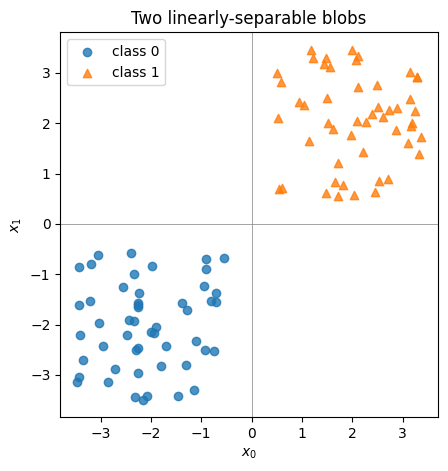

In [3]:
N_PER_CLASS = 50
N_SAMPLES = 2 * N_PER_CLASS
SPREAD = 1.5


def make_blobs(rng):
    centers = ((-2.0, -2.0), (2.0, 2.0))
    X = np.zeros((N_SAMPLES, 2))
    y = np.zeros(N_SAMPLES, dtype=int)
    i = 0
    for c in (0, 1):
        for _ in range(N_PER_CLASS):
            X[i, 0] = centers[c][0] + SPREAD * rng.signed()
            X[i, 1] = centers[c][1] + SPREAD * rng.signed()
            y[i] = c
            i += 1
    return X, y


X, y = make_blobs(Rng(42))

fig, ax = plt.subplots()
for c, marker, label in [(0, "o", "class 0"), (1, "^", "class 1")]:
    m = y == c
    ax.scatter(X[m, 0], X[m, 1], marker=marker, label=label, alpha=0.8)
ax.axhline(0, color="gray", lw=0.5)
ax.axvline(0, color="gray", lw=0.5)
ax.set_title("Two linearly-separable blobs")
ax.set_xlabel("$x_0$")
ax.set_ylabel("$x_1$")
ax.legend()
ax.set_aspect("equal")
plt.show()

## 5. The perceptron itself

Two weights, one bias. `preactivation` computes $z$; `predict` applies the step. `train_epoch`
is Rosenblatt's rule written out over one fixed-order pass of the data — the same order the C
uses, which is what keeps the two implementations numerically identical.

In [4]:
class Perceptron:
    def __init__(self):
        self.w0 = 0.0
        self.w1 = 0.0
        self.b = 0.0

    def preactivation(self, x0, x1):   # z = w0*x0 + w1*x1 + b
        return self.w0 * x0 + self.w1 * x1 + self.b

    def predict(self, x0, x1):         # yhat = step(z)
        return 1 if self.preactivation(x0, x1) >= 0.0 else 0


def accuracy(p, X, y, n):
    return sum(p.predict(float(X[i, 0]), float(X[i, 1])) == int(y[i]) for i in range(n)) / n


def train_epoch(p, lr, X, y, n):
    """One pass of Rosenblatt's rule over all samples, fixed order (mirrors the C)."""
    for i in range(n):
        x0, x1 = float(X[i, 0]), float(X[i, 1])
        yhat = p.predict(x0, x1)
        err = float(int(y[i]) - yhat)   # -1, 0, or +1
        p.w0 += lr * err * x0
        p.w1 += lr * err * x1
        p.b += lr * err

## 6. Watch the boundary rotate into place

This is what a notebook is *for*: train, but snapshot the weights every epoch and **plot the line
moving**. Left — the decision boundary at epochs 0, 1, 2, 5, 20 as it swings to separate the
classes. Right — accuracy climbing to **1.000**. (`blobs_inline` is saved for the verify step.)

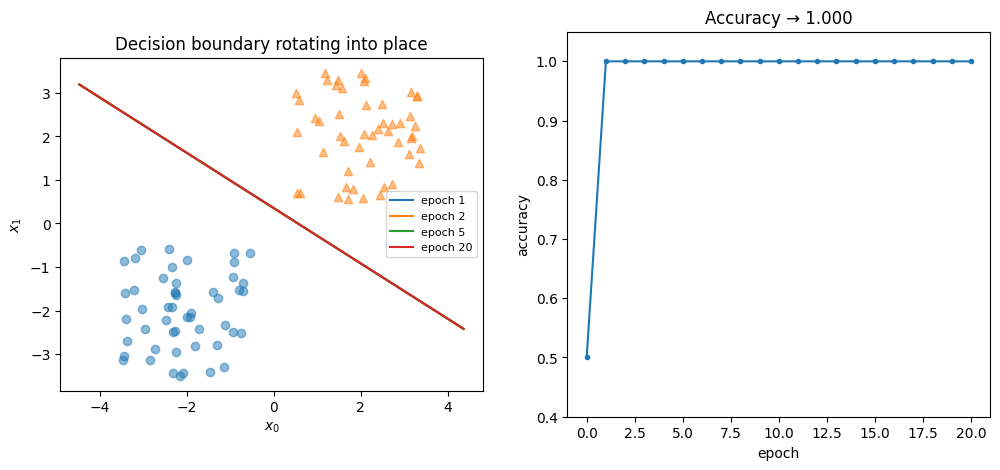

inline blobs (w0, w1, b, acc) = (0.17953090200682775, 0.28236097131567467, -0.1, 1.0)


In [5]:
lr, epochs = 0.1, 20
p = Perceptron()
history = [(0, p.w0, p.w1, p.b, accuracy(p, X, y, N_SAMPLES))]   # (epoch, w0, w1, b, acc)
for e in range(1, epochs + 1):
    train_epoch(p, lr, X, y, N_SAMPLES)
    history.append((e, p.w0, p.w1, p.b, accuracy(p, X, y, N_SAMPLES)))

fig, (axb, axa) = plt.subplots(1, 2, figsize=(12, 5))

# left: the decision boundary rotating into place over epochs
for c, marker in [(0, "o"), (1, "^")]:
    m = y == c
    axb.scatter(X[m, 0], X[m, 1], marker=marker, alpha=0.5)
xs = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 2)
for e in [0, 1, 2, 5, epochs]:
    _, w0, w1, b, _ = history[e]
    if abs(w1) > 1e-12:            # boundary: w0*x0 + w1*x1 + b = 0  ->  x1 = -(w0*x0 + b)/w1
        axb.plot(xs, -(w0 * xs + b) / w1, label=f"epoch {e}", lw=1.5)
axb.set_title("Decision boundary rotating into place")
axb.set_xlabel("$x_0$")
axb.set_ylabel("$x_1$")
axb.legend(fontsize=8)
axb.set_aspect("equal")

# right: accuracy climbing to 1.000
axa.plot([h[0] for h in history], [h[4] for h in history], marker=".")
axa.set_xlabel("epoch")
axa.set_ylabel("accuracy")
axa.set_ylim(0.4, 1.05)
axa.set_title(f"Accuracy \u2192 {history[-1][4]:.3f}")
plt.show()

blobs_inline = (p.w0, p.w1, p.b, accuracy(p, X, y, N_SAMPLES))
print("inline blobs (w0, w1, b, acc) =", blobs_inline)

### Optional: poke at it (learning rate & epochs)

If `ipywidgets` is installed, drag the sliders and watch the final boundary respond. If it isn't,
this cell prints a note and the static figure above is your answer — the notebook still runs clean
top-to-bottom. (The site ships a richer interactive widget; this is the quick in-notebook version.)

In [6]:
try:
    from ipywidgets import interact, FloatSlider, IntSlider

    def _demo(lr=0.1, epochs=20):
        pp = Perceptron()
        for _ in range(epochs):
            train_epoch(pp, lr, X, y, N_SAMPLES)
        fig, ax = plt.subplots()
        for c, marker in [(0, "o"), (1, "^")]:
            m = y == c
            ax.scatter(X[m, 0], X[m, 1], marker=marker, alpha=0.5)
        if abs(pp.w1) > 1e-12:
            ax.plot(xs, -(pp.w0 * xs + pp.b) / pp.w1, "k-")
        ax.set_aspect("equal")
        ax.set_title(f"lr={lr}, epochs={epochs}, acc={accuracy(pp, X, y, N_SAMPLES):.3f}")
        plt.show()

    interact(_demo,
             lr=FloatSlider(min=0.01, max=1.0, step=0.01, value=0.1),
             epochs=IntSlider(min=1, max=50, value=20))
except ImportError:
    print("ipywidgets not installed \u2014 skipping the slider (the static figure above still holds).")

ipywidgets not installed — skipping the slider (the static figure above still holds).


## 7. The wall: XOR

XOR is the simplest problem a single perceptron **cannot** solve: the two classes can't be split
by any straight line. Train for 100 epochs and accuracy stalls at **0.500** — no better than a
coin flip. This wall (Minsky & Papert, 1969) is exactly what a *hidden layer* fixes in
[Module 01](../01-mlp-backprop/).

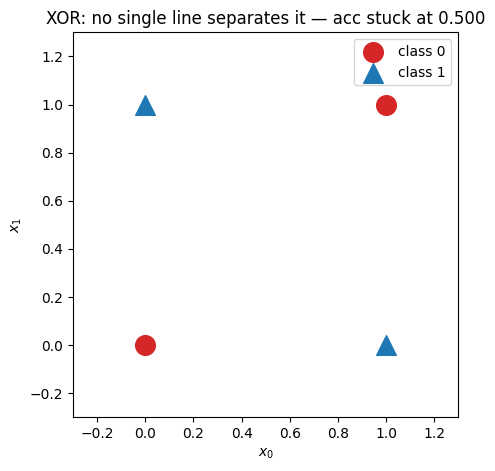

inline xor (w0, w1, b, acc) = (-0.1, 0.0, 0.0, 0.5)


In [7]:
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y_xor = np.array([0, 1, 1, 0])

pxor = Perceptron()
for _ in range(100):
    for i in range(4):
        x0, x1 = float(X_xor[i, 0]), float(X_xor[i, 1])
        err = float(int(y_xor[i]) - pxor.predict(x0, x1))
        pxor.w0 += 0.1 * err * x0
        pxor.w1 += 0.1 * err * x1
        pxor.b += 0.1 * err
xor_inline = (pxor.w0, pxor.w1, pxor.b, accuracy(pxor, X_xor, y_xor, 4))

fig, ax = plt.subplots()
for c, marker, color in [(0, "o", "tab:red"), (1, "^", "tab:blue")]:
    m = y_xor == c
    ax.scatter(X_xor[m, 0], X_xor[m, 1], marker=marker, c=color, s=200, label=f"class {c}")
ax.set_title(f"XOR: no single line separates it \u2014 acc stuck at {xor_inline[3]:.3f}")
ax.set_xlabel("$x_0$")
ax.set_ylabel("$x_1$")
ax.legend()
ax.set_aspect("equal")
ax.margins(0.3)
plt.show()

print("inline xor (w0, w1, b, acc) =", xor_inline)

## 8. Verify: the notebook agrees with the canonical code

The cells above **rebuilt** the perceptron for teaching. To guarantee this notebook never quietly
drifts from the source of truth, we now import the canonical [`python/perceptron.py`](python/perceptron.py)
— the same file the C↔Python agreement test checks — and assert our inline results match it to
`1e-12`. If someone edits one and not the other, this cell fails loudly.

In [8]:
import sys
from pathlib import Path

# Locate the canonical python/perceptron.py (sibling of this notebook) and import it.
here = Path.cwd()
for cand in (here / "python", here, here / "topics" / "00-perceptron" / "python"):
    if (cand / "perceptron.py").exists():
        sys.path.insert(0, str(cand))
        break
else:
    raise FileNotFoundError("could not locate python/perceptron.py next to the notebook")

import perceptron as canon


def _close(a, b, tol=1e-12):
    return all(abs(x - y) <= tol * max(1.0, abs(x), abs(y)) for x, y in zip(a, b))


assert _close(blobs_inline, canon.run_blobs()), (blobs_inline, canon.run_blobs())
assert _close(xor_inline, canon.run_xor()), (xor_inline, canon.run_xor())
print("OK \u2014 notebook agrees with python/perceptron.py (blobs & xor, tol=1e-12)")

OK — notebook agrees with python/perceptron.py (blobs & xor, tol=1e-12)


## 9. Optional: PyTorch validation

From **Module 01 onward** every module includes an optional PyTorch *validation cell* that
cross-checks our from-scratch **gradients** against autograd (never as the teaching implementation
— see [`CLAUDE.md`](../../CLAUDE.md)). The perceptron has nothing to validate that way: its step
function isn't differentiable and Rosenblatt's rule isn't gradient descent. So there's no torch
cell here — the meaningful check is the C↔Python agreement above. The pattern starts once real
backprop appears next door.

---

### What's next

The XOR wall is the cliffhanger. **[Module 01 — MLP + Backpropagation](../01-mlp-backprop/)** adds a
hidden layer and learns it with the chain rule written out by hand, and XOR falls. See this
module's [`README.md`](README.md) and the [blog post](../../site/src/content/posts/00-perceptron.mdx)
for the C/Python/Manim/widget full stack.